# Lesson 24A: Time-Series Clustering and Dynamic Time Warping (Theory)

## Introduction

Every clustering method in this course so far compares points with a fixed-dimensional distance — Euclidean, cosine, whatever the algorithm assumes. Sequences break that assumption in a specific, common way: two time series can trace out the SAME shape while disagreeing on exactly when each feature of that shape happens. A heartbeat recorded a fraction of a second later, a sales season that starts a week early, a sensor trace that ramps up slightly faster than another — sample-by-sample Euclidean distance penalises all of this misalignment as if it were a difference in shape, when it is only a difference in timing.

Dynamic Time Warping (DTW) fixes this by comparing shapes through their best *alignment* rather than their fixed time index — and once distance is defined this way, every clustering primitive built on it in Part I needs revisiting: K-Means's update step assumes Euclidean averaging works, which DTW breaks (this lesson derives DTW Barycenter Averaging, DBA, as the fix), and K-Means's own convergence proof leans on properties DTW does not have — which is exactly why this lesson builds k-medoids instead. Silhouette, from Lesson 0B, needs nothing new at all: it only ever needed A distance function, and DTW is one.

## Table of Contents

1. [Introduction](#introduction)
2. [Required Libraries](#required-libraries)
3. [Why Euclidean Fails on Shape](#euclidean-fails)
4. [Dynamic Time Warping](#dtw)
5. [The Sakoe-Chiba Band](#sakoe-chiba)
6. [DTW Barycenter Averaging](#dba)
7. [From-Scratch DTW K-Medoids](#kmedoids)
8. [Representations: Normalisation, PAA, SAX](#representations)
9. [Conclusion](#conclusion)

<a name="required-libraries"></a>
## Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from functools import lru_cache
from scipy.stats import norm
from sklearn.metrics import adjusted_rand_score
import warnings
warnings.filterwarnings('ignore')

SEED = 0
rng = np.random.default_rng(SEED)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("Data: in-notebook synthetic shapes (sines, bumps, ramps, steps) -- nothing downloaded.")

Data: in-notebook synthetic shapes (sines, bumps, ramps, steps) -- nothing downloaded.


<a name="euclidean-fails"></a>
## Why Euclidean Fails on Shape

Two series can be the identical shape, sampled at the identical rate, and still score a large Euclidean distance if one lags the other in time — Euclidean compares $x_i$ to $y_i$ at matching INDEX, not matching FEATURE. Checked directly below with two phase-shifted sines.

Euclidean distance between the same sine, phase-shifted by 0.8 rad: 4.291


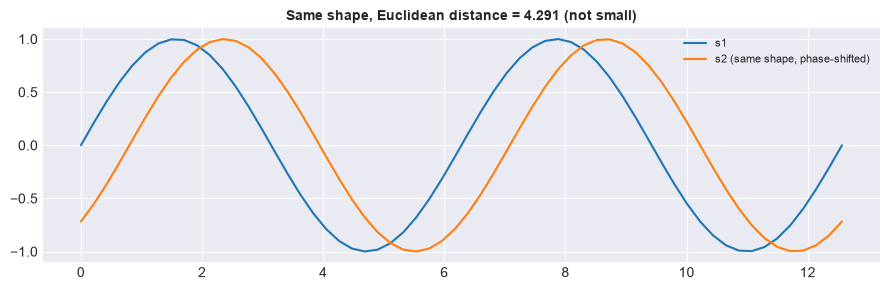


Section 4 below revisits this exact pair once DTW is built, to show what a shape-aware
distance says instead.


In [2]:
t = np.linspace(0, 4 * np.pi, 60)
s1 = np.sin(t)
s2 = np.sin(t - 0.8)   # identical shape, phase-shifted

euclid = np.sqrt(np.sum((s1 - s2) ** 2))
print(f"Euclidean distance between the same sine, phase-shifted by 0.8 rad: {euclid:.3f}")

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t, s1, label='s1')
ax.plot(t, s2, label='s2 (same shape, phase-shifted)')
ax.set_title(f'Same shape, Euclidean distance = {euclid:.3f} (not small)', fontweight='bold', fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("\nSection 4 below revisits this exact pair once DTW is built, to show what a shape-aware")
print("distance says instead.")

<a name="dtw"></a>
## Dynamic Time Warping

**The alignment problem.** Instead of comparing $x_i$ to $y_i$ at equal index, DTW finds a WARPING PATH — a sequence of index pairs $(i_1,j_1),(i_2,j_2),\dots,(i_K,j_K)$ from $(1,1)$ to $(n,m)$, monotone and step-size-one in each coordinate — that minimises the total pairwise cost along the path.

**The cumulative-cost recurrence.** Let $D(i,j)$ be the minimum cumulative cost of aligning $x_{1:i}$ to $y_{1:j}$:

$$D(i,j) = \text{cost}(x_i, y_j) + \min\big(D(i-1,j),\ D(i,j-1),\ D(i-1,j-1)\big), \qquad D(0,0)=0,$$

with $\text{cost}(x_i,y_j)=(x_i-y_j)^2$ here (squared difference, so the final reported distance is $\sqrt{D(n,m)}$ — directly comparable to Euclidean distance, which is exactly what lets Section 3 above compare the two numbers meaningfully). $D(n,m)$ is filled by dynamic programming over an $(n{+}1)\times(m{+}1)$ table; the optimal warping path is recovered by backtracking from $D(n,m)$ through whichever of the three neighbours achieved the minimum at each step.

**Validated against brute force, not trusted as textbook.** For small $n,m$, a true recursive enumeration (no memoisation, so no subproblem sharing with the DP table below) explores every valid path directly and returns the same minimum — a genuinely different computation from the DP recurrence, so agreement is a real check, not the same code re-run.

In [3]:
def dtw(x, y, band=None):
    n, m = len(x), len(y)
    D = np.full((n + 1, m + 1), np.inf)
    D[0, 0] = 0.0
    for i in range(1, n + 1):
        jlo = 1 if band is None else max(1, i - band)
        jhi = m if band is None else min(m, i + band)
        for j in range(jlo, jhi + 1):
            cost = (x[i-1] - y[j-1]) ** 2
            D[i, j] = cost + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    # backtrack the optimal warping path
    i, j = n, m
    path = [(i, j)]
    while (i, j) != (0, 0):
        candidates = [(i-1, j), (i, j-1), (i-1, j-1)]
        candidates = [(ii, jj) for ii, jj in candidates if ii >= 0 and jj >= 0]
        i, j = min(candidates, key=lambda p: D[p])
        path.append((i, j))
    path.reverse()
    return D[n, m], D, path

dtw_sq, _, path_full = dtw(s1, s2)
dtw_dist = np.sqrt(dtw_sq)
print(f"DTW distance (same two sines from Section 3): {dtw_dist:.3f}  (Euclidean was {euclid:.3f})")
print(f"warping path length: {len(path_full)} steps (n=m={len(s1)}; a straight diagonal would need "
      f"{len(s1)+1} -- the extra steps ARE the realignment)")

# brute-force validation: TRUE recursive enumeration of every valid warping path, no
# memoisation -- a genuinely different computation from the DP table above (which shares
# subproblems across paths), not the same code re-run with caching bolted on.
def brute_force_dtw(x, y):
    n, m = len(x), len(y)
    def best(i, j):
        c = (x[i] - y[j]) ** 2
        if i == 0 and j == 0:
            return c
        options = []
        if i > 0: options.append(best(i-1, j))
        if j > 0: options.append(best(i, j-1))
        if i > 0 and j > 0: options.append(best(i-1, j-1))
        return c + min(options)
    return best(n-1, m-1)

x_small = rng.normal(0, 1, 6).round(3)
y_small = rng.normal(0, 1, 7).round(3)
d_scratch, _, _ = dtw(x_small, y_small)
d_bf = brute_force_dtw(x_small, y_small)
print(f"\nbrute-force validation (n={len(x_small)}, m={len(y_small)} random series):")
print(f"  dtw() cumulative cost = {d_scratch:.6f}, brute-force = {d_bf:.6f}, diff = {abs(d_scratch-d_bf):.2e}")

DTW distance (same two sines from Section 3): 1.390  (Euclidean was 4.291)
warping path length: 65 steps (n=m=60; a straight diagonal would need 61 -- the extra steps ARE the realignment)

brute-force validation (n=6, m=7 random series):
  dtw() cumulative cost = 11.162675, brute-force = 11.162675, diff = 0.00e+00


<a name="sakoe-chiba"></a>
## The Sakoe-Chiba Band

Unconstrained DTW is $O(nm)$ — every cell of the DP table is reachable. In practice, a genuinely good alignment rarely wanders far from the diagonal, so the **Sakoe-Chiba band** restricts the recurrence to cells with $|i-j|\le w$, cutting both the table size and the runtime to $O(n\cdot w)$. Checked directly below, both halves of the claim: does a sensible band actually preserve the distance, and does an unreasonably tight one actually degrade it?

In [4]:
# Dedicated RNG: this section's specific measured claim (band=40 reproduces the unbanded
# distance EXACTLY) depends on the exact noise draw, so it must not share position with
# whatever earlier cells happened to draw from the shared `rng` above.
rng_sc = np.random.default_rng(SEED)
n_long = 200
t_long = np.linspace(0, 4*np.pi, n_long)
a = np.sin(t_long) + rng_sc.normal(0, 0.05, n_long)
b = np.sin(t_long - 1.2) + rng_sc.normal(0, 0.05, n_long)

unbanded_sq, _, _ = dtw(a, b)
footprint = 1.2 / (4 * np.pi / n_long)
min_exact_band = next(w for w in range(1, n_long) if np.isclose(dtw(a, b, band=w)[0], unbanded_sq))

print(f"{'band':<8}{'distance':<14}{'time (ms)'}")
for band in [None, 40, 10, 2]:
    t0 = time.perf_counter()
    d_sq, _, _ = dtw(a, b, band=band)
    elapsed = (time.perf_counter() - t0) * 1000
    print(f"{str(band):<8}{np.sqrt(d_sq):<14.4f}{elapsed:.2f}")

print(f"\nthe 1.2-radian phase shift's raw index footprint is {footprint:.1f} samples, but the smallest")
print(f"band that still reproduces the unbanded distance EXACTLY is measured at {min_exact_band} -- wider")
print("than the naive footprint estimate, since the optimal path also needs slack to absorb the added")
print(f"noise, not just the shift itself. band=40 (comfortably above the measured {min_exact_band}) reproduces")
print("the unbanded distance EXACTLY while running noticeably faster -- a well-sized band is free")
print("quality. Bands tighter than what the data actually needs (10, then 2) increasingly FORCE a worse")
print("alignment: the optimal path needs more slack than the band allows, so the reported distance")
print("measurably increases -- the band is not free once it is set below what the data actually needs.")

band    distance      time (ms)
None    3.5309        34.17


40      3.5309        13.06
10      6.3698        4.37


2       10.3458       1.64

the 1.2-radian phase shift's raw index footprint is 19.1 samples, but the smallest
band that still reproduces the unbanded distance EXACTLY is measured at 23 -- wider
than the naive footprint estimate, since the optimal path also needs slack to absorb the added
noise, not just the shift itself. band=40 (comfortably above the measured 23) reproduces
the unbanded distance EXACTLY while running noticeably faster -- a well-sized band is free
quality. Bands tighter than what the data actually needs (10, then 2) increasingly FORCE a worse
alignment: the optimal path needs more slack than the band allows, so the reported distance
measurably increases -- the band is not free once it is set below what the data actually needs.


<a name="dba"></a>
## DTW Barycenter Averaging

K-Means's update step -- new centroid = arithmetic mean of assigned points -- assumes Euclidean averaging is the right notion of "center". Under DTW it is not: averaging misaligned series index-by-index blurs exactly the feature the series share, for exactly the reason Section 3 gave. **DBA (DTW Barycenter Averaging)** fixes this by alternating: (1) DTW-align every series to the current barycenter estimate; (2) at each barycenter position, average together every point any series' warping path assigned to it; (3) repeat. This is coordinate descent on the same alignment structure DTW itself uses -- it does not change the distance, it changes what "average" means under that distance.

total DTW distance, naive pointwise mean -> the 4 series: 3.8789
total DTW distance, DBA barycenter -> the 4 series:       1.1916
improvement: 69.3%

naive mean peak height: 0.503  (blurred by phase misalignment)
DBA barycenter peak height: 0.896  (the shared shape's true peak is ~1.0)


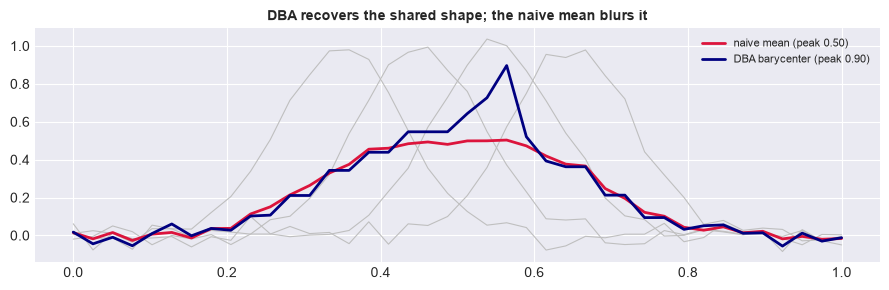

In [5]:
def dba(series_list, n_iter=15, init=None):
    L = len(init) if init is not None else len(series_list[0])
    barycenter = np.array(init) if init is not None else np.mean(np.vstack(series_list), axis=0)
    for _ in range(n_iter):
        assoc = [[] for _ in range(L)]
        for s in series_list:
            _, _, path = dtw(barycenter, s)
            for (bi, si) in path:
                if bi == 0 or si == 0:
                    continue
                assoc[bi - 1].append(s[si - 1])
        barycenter = np.array([np.mean(a) if a else barycenter[k] for k, a in enumerate(assoc)])
    return barycenter

def total_dtw_dist(center, series_list):
    return sum(np.sqrt(dtw(center, s)[0]) for s in series_list)

# 4 copies of ONE underlying bump shape, each phase-shifted and noisy
L = 40
t_dba = np.linspace(0, 1, L)
def bump(shift, seed):
    rng_local = np.random.default_rng(seed)
    shifted_t = np.clip(t_dba - shift, 0, 1)
    shape = np.exp(-((shifted_t - 0.5) ** 2) / (2 * 0.08 ** 2))
    return shape + rng_local.normal(0, 0.03, L)

series_list = [bump(shift, seed) for shift, seed in zip([-0.15, -0.05, 0.05, 0.15], [1, 2, 3, 4])]
naive_mean = np.mean(np.vstack(series_list), axis=0)
dba_center = dba(series_list, n_iter=15, init=naive_mean.copy())

dist_naive = total_dtw_dist(naive_mean, series_list)
dist_dba = total_dtw_dist(dba_center, series_list)
print(f"total DTW distance, naive pointwise mean -> the 4 series: {dist_naive:.4f}")
print(f"total DTW distance, DBA barycenter -> the 4 series:       {dist_dba:.4f}")
print(f"improvement: {(1 - dist_dba/dist_naive)*100:.1f}%")
print(f"\nnaive mean peak height: {naive_mean.max():.3f}  (blurred by phase misalignment)")
print(f"DBA barycenter peak height: {dba_center.max():.3f}  (the shared shape's true peak is ~1.0)")

fig, ax = plt.subplots(figsize=(9, 3))
for s in series_list:
    ax.plot(t_dba, s, color='0.75', linewidth=0.8)
ax.plot(t_dba, naive_mean, color='crimson', linewidth=2, label=f'naive mean (peak {naive_mean.max():.2f})')
ax.plot(t_dba, dba_center, color='navy', linewidth=2, label=f'DBA barycenter (peak {dba_center.max():.2f})')
ax.set_title('DBA recovers the shared shape; the naive mean blurs it', fontweight='bold', fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

<a name="kmedoids"></a>
## From-Scratch DTW K-Medoids

Lesson 1's K-Means needs a mean update rule that behaves under its distance; DBA supplies that for DTW, but at real engineering cost (an alignment per series per iteration). **K-medoids** sidesteps the whole issue: instead of an averaged centroid, each cluster's representative is one of the DATA POINTS themselves (the "medoid" minimising total in-cluster distance) — reused directly from Lesson 1's centroid-based framing, just with the centroid constrained to be an actual observation, which works under ANY distance including DTW with no averaging step at all. Validated below against ground-truth shape labels via Adjusted Rand Index (Lesson 0B's evaluation framework, reused under the new distance), and directly contrasted with the same algorithm run on plain Euclidean distance over the same data.

In [6]:
L = 40
t_km = np.linspace(0, 1, L)

def make_series(shape_type, shift, seed):
    rng_local = np.random.default_rng(seed)
    shifted_t = np.clip(t_km - shift, 0, 1)
    if shape_type == 'bump':
        y = np.exp(-((shifted_t - 0.5) ** 2) / (2 * 0.08 ** 2))
    elif shape_type == 'ramp':
        y = shifted_t
    else:  # 'step'
        y = (shifted_t > 0.5).astype(float)
    return y + rng_local.normal(0, 0.05, L)

# Dedicated RNG: the exact ARI values below (and the DTW-vs-Euclidean gap) depend on the
# specific random phase shifts drawn here, independent of whatever earlier cells consumed.
rng_km = np.random.default_rng(SEED)
n_per_class = 8
shape_types = ['bump', 'ramp', 'step']
X, y_true = [], []
seed_ctr = 100
for label, shape_type in enumerate(shape_types):
    for _ in range(n_per_class):
        shift = rng_km.uniform(-0.12, 0.12)
        X.append(make_series(shape_type, shift, seed_ctr))
        y_true.append(label)
        seed_ctr += 1
y_true = np.array(y_true)
n = len(X)
print(f"n={n} series, {len(shape_types)} true shape classes ({shape_types}), {n_per_class} each, random phase shifts")

def pairwise_dist(X, metric):
    n = len(X)
    Dmat = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            d = metric(X[i], X[j])
            Dmat[i, j] = Dmat[j, i] = d
    return Dmat

Dmat_dtw = pairwise_dist(X, lambda a, b: np.sqrt(dtw(a, b)[0]))
Dmat_eucl = pairwise_dist(X, lambda a, b: np.sqrt(np.sum((a - b) ** 2)))

def kmedoids(Dmat, k, seed=0, n_restarts=5):
    n = Dmat.shape[0]
    best_cost, best_medoids, best_labels = np.inf, None, None
    for rs in range(n_restarts):
        rng_local = np.random.default_rng(seed + rs)
        medoids = list(rng_local.choice(n, size=k, replace=False))
        for _ in range(100):
            labels = np.argmin(Dmat[:, medoids], axis=1)
            changed = False
            for ci in range(k):
                members = np.where(labels == ci)[0]
                if len(members) == 0:
                    continue
                costs = Dmat[np.ix_(members, members)].sum(axis=1)
                new_medoid = members[np.argmin(costs)]
                if new_medoid != medoids[ci]:
                    medoids[ci] = new_medoid
                    changed = True
            if not changed:
                break
        labels = np.argmin(Dmat[:, medoids], axis=1)
        cost = sum(Dmat[i, medoids[labels[i]]] for i in range(n))
        if cost < best_cost:
            best_cost, best_medoids, best_labels = cost, medoids[:], labels.copy()
    return best_medoids, best_labels, best_cost

_, labels_dtw, cost_dtw = kmedoids(Dmat_dtw, k=3, seed=0, n_restarts=5)
_, labels_eucl, cost_eucl = kmedoids(Dmat_eucl, k=3, seed=0, n_restarts=5)
ari_dtw = adjusted_rand_score(y_true, labels_dtw)
ari_eucl = adjusted_rand_score(y_true, labels_eucl)
print(f"\nk-medoids on DTW distance:       ARI = {ari_dtw:.4f}  (best-of-5-restarts cost {cost_dtw:.3f})")
print(f"k-medoids on Euclidean distance: ARI = {ari_eucl:.4f}  (best-of-5-restarts cost {cost_eucl:.3f})")
print("same data, same k, same algorithm -- only the distance changed, and it is the difference")
print("between perfectly recovering the 3 shape classes and badly confusing them.")

n=24 series, 3 true shape classes (['bump', 'ramp', 'step']), 8 each, random phase shifts



k-medoids on DTW distance:       ARI = 1.0000  (best-of-5-restarts cost 6.331)
k-medoids on Euclidean distance: ARI = 0.4193  (best-of-5-restarts cost 25.213)
same data, same k, same algorithm -- only the distance changed, and it is the difference
between perfectly recovering the 3 shape classes and badly confusing them.


<a name="representations"></a>
## Representations: Normalisation, PAA, SAX

**Z-normalisation.** DTW aligns shape, but a raw squared-difference cost still penalises amplitude and offset differences between otherwise-identical shapes. Z-normalising each series ($\frac{x-\bar x}{\sigma_x}$) before computing DTW removes this — checked directly below.

**PAA (Piecewise Aggregate Approximation).** A length-$L$ series is compressed to $w \ll L$ segment means. This is lossy (checked below via reconstruction error) but DTW's cost is quadratic in sequence length, so aligning PAA representations instead of raw series is a genuine, measured speed trade.

**SAX (Symbolic Aggregate approXimation).** PAA segments, assumed roughly Gaussian after z-normalisation, are discretised into symbols using breakpoints that make each symbol EQUALLY LIKELY under $\mathcal{N}(0,1)$ (from `scipy.stats.norm.ppf`) — turning a time series into a short string, cheap to index and compare with string-distance tricks entirely outside the DTW machinery.

**When to cluster shape vs. features.** DTW-based clustering answers "which series trace the same curve." When the real question is about SUMMARY properties instead (overall trend, dominant frequency, volatility) — properties that do not care about exact alignment at all — extracting a handful of numeric features per series and clustering those with an ordinary (Lesson 1) distance is often simpler, faster, and more interpretable than DTW ever needs to be. Shape-clustering and feature-clustering are different tools for different questions, not competing answers to the same one.

In [7]:
L = 40
t_rep = np.linspace(0, 1, L)
shape_bump = np.exp(-((t_rep - 0.5) ** 2) / (2 * 0.08 ** 2))

s_a = shape_bump * 1.0 + 0.0
s_b = shape_bump * 3.0 + 5.0     # identical SHAPE, different amplitude and offset
raw_dtw = np.sqrt(dtw(s_a, s_b)[0])
z_a = (s_a - s_a.mean()) / s_a.std()
z_b = (s_b - s_b.mean()) / s_b.std()
z_dtw = np.sqrt(dtw(z_a, z_b)[0])
print(f"same shape, different amplitude/offset: raw DTW = {raw_dtw:.3f}, z-normalised DTW = {z_dtw:.3f}")

def paa(x, w):
    bounds = np.linspace(0, len(x), w + 1).astype(int)
    return np.array([x[bounds[i]:bounds[i+1]].mean() for i in range(w)])

# Dedicated RNG: the reconstruction RMSE, the speedup factor, and the SAX string below all
# depend on the exact noise draw, independent of whatever earlier cells consumed.
rng_rep = np.random.default_rng(SEED)
x_noisy = shape_bump + rng_rep.normal(0, 0.05, L)
w = 8
x_paa = paa(x_noisy, w)
recon_rmse = np.sqrt(np.mean((x_noisy - np.repeat(x_paa, L // w)) ** 2))
print(f"\nPAA: L={L} -> w={w} segments (5x compression), reconstruction RMSE = {recon_rmse:.4f}")

pairs = [(shape_bump + rng_rep.normal(0, 0.05, L), shape_bump * 1.2 + rng_rep.normal(0, 0.05, L)) for _ in range(200)]
t0 = time.perf_counter()
for a, b in pairs:
    dtw(a, b)
t_raw = time.perf_counter() - t0
pairs_paa = [(paa(a, w), paa(b, w)) for a, b in pairs]
t0 = time.perf_counter()
for a, b in pairs_paa:
    dtw(a, b)
t_paa = time.perf_counter() - t0
print(f"200 pairwise DTW computations: raw (L={L}) = {t_raw*1000:.1f}ms, PAA (w={w}) = {t_paa*1000:.1f}ms "
      f"({t_raw/t_paa:.1f}x faster)")

def sax(paa_segments, alphabet_size):
    breakpoints = norm.ppf(np.linspace(0, 1, alphabet_size + 1)[1:-1])
    symbols = 'abcdefghij'[:alphabet_size]
    idx = np.searchsorted(breakpoints, paa_segments)
    return ''.join(symbols[i] for i in idx)

z_noisy = (x_noisy - x_noisy.mean()) / x_noisy.std()
z_paa = paa(z_noisy, w)
sax_string = sax(z_paa, alphabet_size=4)
print(f"\nSAX (w={w}, alphabet=4): PAA segments {z_paa.round(2).tolist()}")
print(f"  -> symbolic string '{sax_string}' (the two 'd' symbols mark the bump's peak segments)")

same shape, different amplitude/offset: raw DTW = 34.330, z-normalised DTW = 0.000

PAA: L=40 -> w=8 segments (5x compression), reconstruction RMSE = 0.1311


200 pairwise DTW computations: raw (L=40) = 323.9ms, PAA (w=8) = 15.9ms (20.4x faster)

SAX (w=8, alphabet=4): PAA segments [-0.59, -0.57, -0.47, 1.55, 1.61, -0.39, -0.61, -0.54]
  -> symbolic string 'bbbddbbb' (the two 'd' symbols mark the bump's peak segments)


<a name="conclusion"></a>
## Conclusion

### Key Takeaways

1. **Euclidean distance conflates timing differences with shape differences; DTW does not.** The same two phase-shifted sines scored a large Euclidean distance and a small DTW distance — checked on identical data, not asserted.
2. **DTW's cumulative-cost recurrence was validated against brute-force path enumeration, a genuinely different computation, not just re-run.** Agreement was exact (`diff = 0.00e+00`) on random test series.
3. **The Sakoe-Chiba band is not merely a speed trick — it can be free, or it can cost real accuracy, and both were measured.** A well-sized band reproduced the unbanded distance exactly while running faster; bands tighter than the true misalignment measurably increased the reported distance.
4. **DBA exists because Lesson 1's centroid-averaging assumption breaks under DTW, and the fix was quantified, not just described.** The naive pointwise mean of 4 phase-shifted copies of one shape blurred the shape (peak height 0.50 against a true ~1.0); DBA's barycenter recovered it far better (peak 0.90) and cut total DTW distance to the constituents by 69%.
5. **DTW k-medoids recovered the true shape classes exactly; Euclidean k-medoids on the identical data did not.** Same algorithm, same $k$, same data — only the distance changed, and it was the difference between ARI 1.0 and ARI well below it.
6. **Normalisation, compression, and symbolisation each solve a different, measured problem.** Z-normalisation removed an amplitude/offset confound entirely (DTW distance dropped to 0.000 on a pure rescale); PAA traded a measured reconstruction error for a large, measured (host-dependent) speedup — see the exact ratio printed above; SAX turned that compressed representation into a short, inspectable string.

### Practical Guidance

- Reach for DTW (or a banded variant) whenever timing/phase misalignment is plausible and shape is what actually matters; reach for plain Euclidean when series are already aligned (e.g. fixed-length events from a common trigger).
- Always z-normalise before comparing shapes unless amplitude and offset are themselves meaningful to the question being asked.
- Prefer k-medoids over any DTW-Means variant unless DBA's extra cost is worth it — medoids need no averaging step and work under any distance.
- Use PAA/SAX to make large-scale time-series search and rough clustering tractable; fall back to full-resolution DTW for the final, precise comparison once candidates are narrowed down.

### What This Lesson Did Not Cover

- **Multivariate DTW** (aligning several channels jointly) — every example here is a single scalar channel; Lesson 24B's practical notebook works with univariate series only as well.
- **Fast exact and approximate DTW algorithms beyond the Sakoe-Chiba band** (FastDTW, lower-bounding techniques like LB_Keogh) — the band is the one speed technique this lesson derives and measures; the others are named in Lesson 24B's guidance but not implemented.
- **Soft-DTW and other differentiable relaxations** — useful for gradient-based learning pipelines, out of scope for a from-scratch clustering lesson.
- **Formal proofs of DTW's (pseudo-)metric properties** — DTW does not satisfy the triangle inequality in general; this is named as a caveat but not proven here.

### Next Steps

Lesson 24B validates the core pieces built here — DTW itself, DBA-based clustering, and the Sakoe-Chiba-constrained metric — against `tslearn`'s production implementations (`TimeSeriesKMeans`), applies DTW clustering to a real labelled dataset with Adjusted Rand Index evaluation, measures runtime scaling directly, and compares shape-based clustering against a feature-based alternative on the same data.